# 03-08 - The Honest Accuracy

The orthomosaic of 03-06 is sharp to a few centimetres. The question this notebook asks is a different one, which is whether it is in the right place. Sharpness is what the camera and the software give; position is what the aircraft's receiver gave, and a consumer receiver knows where it is to a metre or two. The software reports how well the photographs agree with each other and with the receiver, and that number is not an accuracy, because every point it rests on is a point the software used. An honest accuracy needs something the software never saw.

We flew without ground control, on purpose, so the only things the software never saw are other pictures of the same ground: the federal flights of 2022 and 2023 and the State's flight of 2020, each placed by a surveyor's methods and each with an error of its own. We measure how far the orthomosaic must move to lie on each of them, using a method that we first test by moving our own picture by a known amount and asking it to find the move. We measure how far the references disagree among themselves, which is the floor under any check of this kind. We put the receiver's own account of its error beside the result, and we ask what ground control targets would have bought. Every number belongs to the flight named in `data/flight.json`; the notebook was written on the pre-flight of 17 September 2026.

Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
from rasterio.transform import Affine
from rasterio.warp import Resampling, reproject
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight = json.load(open("data/flight.json"))
reference = json.load(open("data/ground_truth.json"))["p03"]
control = reference["control"]
placed_by = "laid and measured" if flight["gcp_used"] else "none laid, so the receiver alone placed the block"
print(f"this notebook reads the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at {flight['altitude_agl_m']} m, ground control: {placed_by}")

this notebook reads the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, ground control: none laid, so the receiver alone placed the block


## Three kinds of point, and what we have

The lecture named the kinds of point a survey rests on. Ground control points are positions known on the ground and found in the photographs, and the software pulls the block onto them. Check points are measured the same way but withheld from the solution, so that their residuals are an honest measure of the result. Either kind is called a panelled point when a target is laid before the flight so that it is unmistakable in the photographs. And the software finds its own tie points, thousands per photograph, which 03-06 counted; those are not control of any kind, because nobody measured them on the ground. We laid no targets and measured no points, so the block was placed by the receiver in the aircraft alone, and the software's report says how the receiver's positions compared with where it decided the cameras had been:

In [2]:
gps = json.load(open("data/report.json"))["stats"]["gps_errors"]
print("the receiver's positions against the adjusted cameras, metres")
print(f"  mean     east {gps['mean']['x']:+.4f}  north {gps['mean']['y']:+.4f}  up {gps['mean']['z']:+.4f}")
print(f"  spread   east {gps['std']['x']:+.2f}  north {gps['std']['y']:+.2f}  up {gps['std']['z']:+.2f}")
print(f"  average error {gps['average_error']:.2f} m   reference {control['receiver_error_reported_m']:.2f} m")
print(f"  90 percent of the cameras lie within {gps['ce90']:.2f} m in plan and {gps['le90']:.2f} m in height of where the block puts them")

the receiver's positions against the adjusted cameras, metres
  mean     east +0.0000  north +0.0024  up +0.0026
  spread   east +0.51  north +0.52  up +0.71
  average error 0.90 m   reference 0.90 m
  90 percent of the cameras lie within 1.10 m in plan and 1.32 m in height of where the block puts them


Read the first line before the others. The mean is zero, in all three directions, to within a few millimetres. That is not because the receiver was right on average; it is because the software anchored the block to the receiver's positions, so their mean difference is zero by construction. What the report measures on the second line is the scatter of the receiver's fixes about their own mean, which is a fair statement of how noisy a consumer receiver is from one second to the next, and the average error and the ninety percent figures are that same scatter restated. The report's own third column, which OpenDroneMap calls the error, repeats the scatter for exactly this reason and is left out above. None of it says whether the whole block, mean and all, sits where the ground is. For that we need a reference the software never touched.

## The method, and its self test

We have no surveyed points, but we have three other pictures of the same ground, each placed by a survey we did not make. If the orthomosaic and a reference picture show the same paths and kerbs, the offset between them can be measured by sliding one over the other until they agree, which is what phase correlation does on the edges of the two pictures. Three precautions make it honest. Trees and roofs are masked out of the orthomosaic before matching, because leaves change between seasons and roofs lean differently in every flight, so only bare ground takes part. The reference, less obviously, is left whole. If both pictures carried the same mask, the strongest thing they had in common would be the edge of the mask itself, and the method would report with great confidence that the two masks line up, which says nothing at all about the ground. And the method is tested before it is believed: the orthomosaic is moved by a known two metres east and two north, and the method is asked to find that move. A method that cannot find a shift you put in cannot be trusted to find one you did not.

The pipeline ran that method against every reference, with the self test, and the results travel in `check_windows.csv`:

In [3]:
def phase_shift(a, b):
    '''The move, in cells, that takes b onto a, by phase correlation with a parabolic fit around the peak.'''
    a = (a - a.mean()) / (a.std() + 1e-9)                   # normalise both, so that brightness does not matter
    b = (b - b.mean()) / (b.std() + 1e-9)
    F = np.fft.fft2(a) * np.conj(np.fft.fft2(b))            # one spectrum times the other's conjugate holds the shift as a phase ramp
    r = np.fft.ifft2(F / (np.abs(F) + 1e-9)).real           # divide by the magnitude so only the phase survives, then transform back
    iy, ix = np.unravel_index(int(np.argmax(r)), r.shape)   # the brightest cell is the shift, in whole cells
    h, w = r.shape

    def refine(minus, centre, plus):
        '''A parabola through three neighbouring values, for the fraction of a cell between them.'''
        d = minus - 2 * centre + plus
        return 0.5 * (minus - plus) / d if d < 0 else 0.0

    # a peak near the far side of the array is a negative shift that has wrapped around, and is unwrapped here
    dy = (iy - h if iy > h // 2 else iy) + refine(r[(iy - 1) % h, ix], r[iy, ix], r[(iy + 1) % h, ix])
    dx = (ix - w if ix > w // 2 else ix) + refine(r[iy, (ix - 1) % w], r[iy, ix], r[iy, (ix + 1) % w])
    return dx, dy, float(r.max())                           # the peak's height says how sharply one shift was picked out

def gradient(a):
    '''How steeply brightness changes from cell to cell, which is large at an edge and near zero on flat ground.'''
    gy, gx = np.gradient(a)
    return np.hypot(gx, gy)

print("the method:", control["method"])
print()
checks = pd.read_csv("data/check_windows.csv")
whole = checks[(checks["part"] == "whole") & (checks["injected_e_m"] == 0)].set_index("reference")
tested = checks[(checks["part"] == "whole") & (checks["injected_e_m"] > 0)].set_index("reference")
rows = []
for ref, row in whole.iterrows():
    t = tested.loc[ref]
    # the two rows are the same measurement with and without an injected shift, so their difference is what the method recovered
    recovered_e = row["shift_e_m"] - t["shift_e_m"]
    recovered_n = row["shift_n_m"] - t["shift_n_m"]
    passed = abs(recovered_e - t["injected_e_m"]) < 0.5 and abs(recovered_n - t["injected_n_m"]) < 0.5
    entry = control["references"][ref]
    rows.append({"reference": ref, "east_m": round(row["shift_e_m"], 2), "north_m": round(row["shift_n_m"], 2),
                 "peak": round(row["peak"], 4), "bare_ground": f"{row['ground_share']:.0%}",
                 "self_test_e": round(recovered_e, 2), "self_test_n": round(recovered_n, 2),
                 "verdict": "passed" if passed else "FAILED, not used",
                 "tiles": entry["n_tiles"], "tiles_spread_m": entry["tiles_spread_m"]})
print("the move, east and north, that takes the orthomosaic onto each reference, and what the self test recovered of an injected 2 m east and 2 m north")
print(pd.DataFrame(rows).to_string(index=False))
print()
print(f"consensus of the references that passed: east {control['consensus_e_m']:+.2f} m, north {control['consensus_n_m']:+.2f} m   from {', '.join(control['usable_references'])}")
print(f"of which the NAD 83 against WGS 84 datum accounts for east {control['datum_e_m']:+.2f} m, north {control['datum_n_m']:+.2f} m,")
print(f"and what remains, the receiver's placement of the block, is east {control['receiver_e_m']:+.2f} m, north {control['receiver_n_m']:+.2f} m")

the method: phase correlation of edge images, the orthomosaic masked to bare ground and the reference left whole, with a self test of an injected shift

the move, east and north, that takes the orthomosaic onto each reference, and what the self test recovered of an injected 2 m east and 2 m north
reference  east_m  north_m   peak bare_ground  self_test_e  self_test_n          verdict  tiles  tiles_spread_m
naip_2022    0.65    -3.60 0.0081          8%         1.88         2.25           passed      5           39.00
naip_2023    0.41    -1.47 0.0077         30%         1.98         2.13           passed      8            6.45
   nj2020  -38.07    96.65 0.0053         32%       -31.68       100.33 FAILED, not used      8          107.42

consensus of the references that passed: east +0.53 m, north -2.54 m   from naip_2022, naip_2023
of which the NAD 83 against WGS 84 datum accounts for east +0.64 m, north -1.08 m,
and what remains, the receiver's placement of the block, is east -0.11 m,

One column needs a word before you read the table. The peak is how sharply the correlation picked one shift out of all the others, so a larger peak is a more confident answer, and the peak between two pictures of the same kind is always higher than between a drone's picture and an aeroplane's.

Read the self test columns first, because they decide which lines to believe. Where the method recovered the two metres it was given to within a few decimetres, its measurement of the real offset is worth reading. Where it did not, the reference and the orthomosaic have too little in common for the method to work, which on the pre-flight of 17 September was the State's leaf-off flight, taken in a different season with bare trees and long shadows, and that line is dropped rather than averaged in.

Read the bare ground share and the tile spread next, because they say how much weight a line deserves. A reference with a tenth of its window in bare ground, whose three by three tiles disagree among themselves by tens of metres, has told you much less than one whose tiles agree to a few metres, even when both pass the self test. One line that passes is left out of the consensus altogether, and you can guess which: the second flight of our own aircraft is not an independent reference at all, and the section below is about why.

Then read the three lines under the table, which are the heart of this notebook. The first is the move the surviving references agree on. The second is the part of that move which is not the drone's fault at all: 03-01's first suspect, the NAD 83 against WGS 84 datum, which every library here declines to apply and which is therefore still sitting in the measurement. The third is what is left once that is taken out, and only that last line is the receiver's placement of the block. Compare it with the receiver's own account of itself above. The scatter the software reported is a fraction of a metre and the placement is metres, and the gap between those two numbers is the lesson of this notebook: a receiver's scatter is not its error, and a block placed by a receiver alone is placed to metres, however sharp its pixels.

## Seeing it

Numbers from a correlation deserve a picture. We take the sixty metres of the site with the most bare ground in view, paths, courts and pavement rather than roofs and crowns, put the orthomosaic on the 2023 flight's grid there, and draw the edges of the two pictures over each other, the reference in cyan and the orthomosaic in red, before and after the orthomosaic is moved by the consensus. Where the two agree, red over cyan makes white:

the window with the most bare ground has 91% of it; moving the orthomosaic east +0.53 m and north -2.54 m, 2 and 8 cells of the reference, changes the edge disagreement on bare ground from 0.130 to 0.128


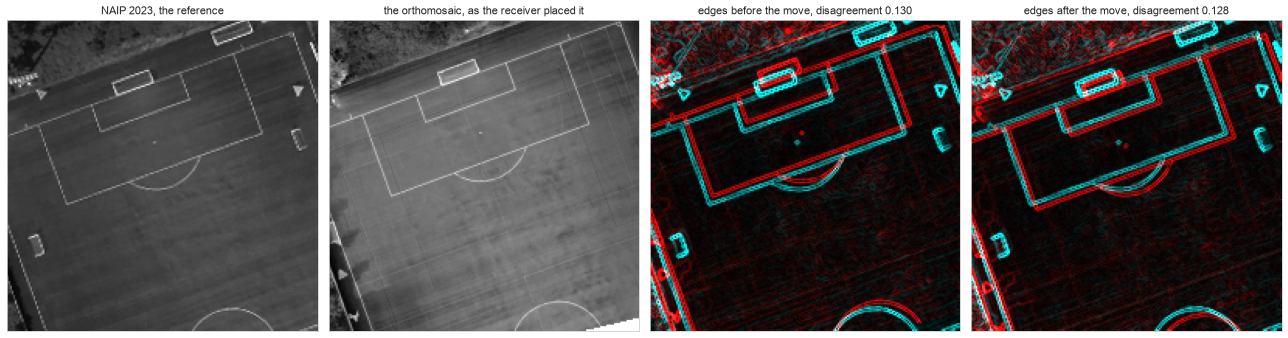

In [4]:
BARE_GROUND_NDVI = 0.2                                     # below this a cell is pavement, path or bare earth rather than leaf
BUILDING_MARGIN_M = 4                                      # and this much is kept clear of every footprint, for the eaves and the lean
consensus = (control["consensus_e_m"], control["consensus_n_m"])
buildings = gpd.read_file("data/site.gpkg", layer="buildings_site")
with rasterio.open("data/naip_2023_site.tif") as naip:
    ref_grey = naip.read([1, 2, 3]).astype("float32").mean(axis=0)
    tr, crs, shape, res = naip.transform, naip.crs, naip.shape, naip.res[0]

def onto_grid(band, src):
    '''One band of an open raster, warped onto the reference grid above, with nothing outside it.'''
    out = np.full(shape, np.nan, "float32")
    reproject(band.astype("float32"), out, src_transform=src.transform, src_crs=src.crs,
              dst_transform=tr, dst_crs=crs, resampling=Resampling.average, dst_nodata=np.nan)
    return out

with rasterio.open("data/naip_2022_site.tif") as n22:      # the 2022 flight has its leaves on, so it says where the ground is bare
    nir, red = onto_grid(n22.read(4), n22), onto_grid(n22.read(1), n22)
not_a_building = geometry_mask(buildings.to_crs(crs).geometry.buffer(BUILDING_MARGIN_M), out_shape=shape, transform=tr, invert=False)
ground_23 = (((nir - red) / (nir + red + 1e-6)) < BARE_GROUND_NDVI) & not_a_building

def ortho_on_grid(move_e=0.0, move_n=0.0):
    '''The orthomosaic's grey on the reference grid, after moving its georeferencing by move_e and move_n metres.
    `Affine.translation` counts in pixels, so the metres are divided by the cell size, and north is negative because
    rows run southwards. Note that this moves the file's georeferencing and not one pixel of its content.'''
    with rasterio.open("data/ortho_10cm.tif") as o:
        moved = o.transform * Affine.translation(move_e / o.transform.a, -move_n / o.transform.a)
        grey = o.read([1, 2, 3]).astype("float32").mean(axis=0)
        grey[o.read_masks(1) == 0] = np.nan                        # outside the model the JPEG holds zeros, which are not a brightness
        out = np.full(shape, np.nan, "float32")
        reproject(grey, out, src_transform=moved, src_crs=o.crs, dst_transform=tr, dst_crs=crs, resampling=Resampling.average, dst_nodata=np.nan)
    return out

before, after = ortho_on_grid(), ortho_on_grid(*consensus)
WINDOW_M = 60                                              # the pictures below are this wide, in metres
window_px = int(round(WINDOW_M / res))
stride_px = window_px // 3
best = None
for r0 in range(0, shape[0] - window_px + 1, stride_px):
    for c0 in range(0, shape[1] - window_px + 1, stride_px):
        sl = (slice(r0, r0 + window_px), slice(c0, c0 + window_px))
        score = float((ground_23 & np.isfinite(before) & np.isfinite(after))[sl].mean())
        if best is None or score > best[0]:
            best = (score, sl)
share, sl = best
gmask = ground_23[sl] & np.isfinite(before[sl]) & np.isfinite(after[sl])

def edges(a):
    '''The picture's edges, scaled to run from zero to one, with the model's rim left out.'''
    inside = np.isfinite(a)
    for _ in range(3):      # each pass shrinks the valid area by one cell all round, keeping clear of the mask's rim, which is not an edge of the ground
        inside &= np.roll(inside, 1, 0) & np.roll(inside, -1, 0) & np.roll(inside, 1, 1) & np.roll(inside, -1, 1)
    gy, gx = np.gradient(np.nan_to_num(a))
    e = np.hypot(gx, gy) * inside
    return np.clip(e / (np.nanpercentile(e[inside], 99) + 1e-9), 0, 1) if inside.any() else e

def overlay(ref, oth):
    return np.dstack([edges(oth), edges(ref), edges(ref)])          # the orthomosaic red, the reference cyan, agreement white

d_before = np.abs(edges(ref_grey[sl]) - edges(before[sl]))[gmask].mean()
d_after = np.abs(edges(ref_grey[sl]) - edges(after[sl]))[gmask].mean()
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
axes[0].imshow(ref_grey[sl], cmap="gray"); axes[0].set_title("NAIP 2023, the reference", fontsize=11)
axes[1].imshow(before[sl], cmap="gray"); axes[1].set_title("the orthomosaic, as the receiver placed it", fontsize=11)
axes[2].imshow(overlay(ref_grey[sl], before[sl])); axes[2].set_title(f"edges before the move, disagreement {d_before:.3f}", fontsize=11)
axes[3].imshow(overlay(ref_grey[sl], after[sl])); axes[3].set_title(f"edges after the move, disagreement {d_after:.3f}", fontsize=11)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
print(f"the window with the most bare ground has {share:.0%} of it; moving the orthomosaic east {consensus[0]:+.2f} m and north {consensus[1]:+.2f} m, {abs(consensus[0]) / res:.0f} and {abs(consensus[1]) / res:.0f} cells of the reference, "
      f"changes the edge disagreement on bare ground from {d_before:.3f} to {d_after:.3f}")

In the third panel every kerb and every path edge appears twice, red where the drone put it and cyan where the federal flight did, a few cells apart; in the fourth they move onto each other, and the number in the titles falls. It does not fall to zero, and it cannot: the two pictures were taken years apart at different resolutions, so their edges never match cell for cell. What we are watching go is the offset, not the difference. The number itself is the average disagreement between the two edge pictures, taken only over the bare ground the method used. Where colour remains after the move, look at what it is: tree crowns and roofs, which the method excluded and which lean differently in the two flights, and the field's surface, which the rebuilding changed between them. A picture of a registration is worth having because it also shows what the number leaves out.

## How far the references disagree

A check against a reference is only as good as the reference, and none of ours is a survey. The federal flights are placed to a few metres by their own specification, the State's flight better, and none of them was made for this. The same method, run between two references, measures the floor under the whole exercise:

In [5]:
# the same bare ground rule as above, now computed on the 2022 flight's own grid, which is the coarser of the two
with rasterio.open("data/naip_2022_site.tif") as n22:
    g22 = n22.read([1, 2, 3]).astype("float32").mean(axis=0)
    nir22, red22 = n22.read(4).astype("float32"), n22.read(1).astype("float32")
    tr22, crs22, shape22, res22 = n22.transform, n22.crs, g22.shape, n22.res[0]
ground_22 = (((nir22 - red22) / (nir22 + red22 + 1e-6)) < BARE_GROUND_NDVI) & geometry_mask(
    buildings.to_crs(crs22).geometry.buffer(BUILDING_MARGIN_M), out_shape=shape22, transform=tr22, invert=False)
with rasterio.open("data/naip_2023_site.tif") as n23:
    g23 = np.full(shape22, np.nan, "float32")
    reproject(n23.read([1, 2, 3]).astype("float32").mean(axis=0), g23, src_transform=n23.transform, src_crs=n23.crs,
              dst_transform=tr22, dst_crs=crs22, resampling=Resampling.average, dst_nodata=np.nan)
edges_2023 = np.nan_to_num(gradient(g23))                                      # the reference, left whole
edges_2022_bare = np.where(ground_22 & np.isfinite(g23), gradient(g22), 0.0)   # and the other flight, masked to bare ground
dx, dy, peak = phase_shift(edges_2023, edges_2022_bare)
print(f"the 2022 flight must move east {dx * res22:+.2f} m and north {-dy * res22:+.2f} m to lie on the 2023 flight (peak {peak:.3f})")
print(f"the orthomosaic's offsets against the two were east {whole.loc['naip_2022', 'shift_e_m']:+.2f}, north {whole.loc['naip_2022', 'shift_n_m']:+.2f} and east {whole.loc['naip_2023', 'shift_e_m']:+.2f}, north {whole.loc['naip_2023', 'shift_n_m']:+.2f} m")

the 2022 flight must move east -0.02 m and north +1.37 m to lie on the 2023 flight (peak 0.053)
the orthomosaic's offsets against the two were east +0.65, north -3.60 and east +0.41, north -1.47 m


Read the first line against the second. The two federal flights, both surveyed products of the same agency, disagree with each other by about a metre, and that disagreement is about the size of the difference between the two offsets they gave for the orthomosaic. So the check has a floor. The orthomosaic's position can be known only about as well as the references know their own, which is to say a metre, and an offset of that size or smaller would have been invisible in this exercise. The offset we measured is larger than the floor, which is why it is worth reporting at all; and it is still an order of magnitude above the pixel. A surveyed target, measured to centimetres, would have lowered the floor a hundredfold, which is what ground control is for.

## Two flights, one receiver

Where a flight was flown twice, the second orthomosaic is another picture of the same ground, made minutes later by the same aircraft and the same receiver. The pre-flight of 17 September was flown that way, the two flights less than a minute apart. Run the method between them:

In [6]:
found = False
for name, info in flight.get("other_flights", {}).items():
    if f"ortho_{name}" not in whole.index:
        continue                                          # that flight has no orthomosaic in the checks
    found = True
    row = whole.loc[f"ortho_{name}"]
    tiles = checks[(checks["reference"] == f"ortho_{name}") & (checks["part"] != "whole")]
    tile_spread = np.median(np.hypot(tiles["shift_e_m"] - row["shift_e_m"], tiles["shift_n_m"] - row["shift_n_m"]))
    print(f"the {flight['altitude_agl_m']:.0f} m orthomosaic moves east {row['shift_e_m']:+.2f} m and north {row['shift_n_m']:+.2f} m to lie on the "
          f"{info['altitude_agl_m']:.0f} m one, {np.hypot(row['shift_e_m'], row['shift_n_m']):.2f} m in all; {len(tiles)} tiles agree to {tile_spread:.2f} m")
    print(f"against the independent references the same orthomosaic was off by {np.hypot(control['consensus_e_m'], control['consensus_n_m']):.2f} m, "
          f"of which {np.hypot(control['receiver_e_m'], control['receiver_n_m']):.2f} m is the receiver once the datum is taken out")
if not found:
    print("this flight has no second orthomosaic to compare with")

this flight has no second orthomosaic to compare with


The two flights agree far more closely than either agrees with the references, and the tiles agree more closely still. Those are the tightest numbers in this notebook, and there is a reason: two pictures taken minutes apart in the same light by the same camera have everything in common. It would be easy to read that agreement as an accuracy, and it is not one. The same receiver, in the same place, under the same satellites, makes nearly the same error twice, so two of its flights agree with each other while both sit metres from where the ground is. Agreement between repeated measurements is repeatability; accuracy needs a reference that did not share the error. This is why the second flight stays out of the consensus above, and why a surveyor's check point is measured with a different instrument than the one that placed the block.

## Heights, and the shape of the block

03-07 already did the vertical half of this check on the lawn, where the 3DEP terrain is the reference. Its numbers belong here beside the horizontal ones:

In [7]:
hts = reference["heights"]
print(f"in height the block sat {hts['vertical_shift_m']:+.2f} m from the 3DEP terrain, of which {hts['geoid18_n_m']} m is the geoid, "
      f"{hts['datum_height_shift_m']:+.2f} m the datum and {hts['receiver_height_error_m']:+.2f} m the receiver; after the shift the lawn agrees to {hts['vertical_shift_mad_m']} m")
print(f"in plan the block sits {np.hypot(control['consensus_e_m'], control['consensus_n_m']):.2f} m from the references' consensus, "
      f"of which {np.hypot(control['datum_e_m'], control['datum_n_m']):.2f} m is the datum and {np.hypot(control['receiver_e_m'], control['receiver_n_m']):.2f} m the receiver")
print(f"in shape the lawn's residual tilts {hts['lawn_tilt_cm_per_100m']} cm per 100 m and keeps {hts['lawn_residual_rms_cm']} cm of RMS after a plane is removed")

in height the block sat -130.13 m from the 3DEP terrain, of which -33.27 m is the geoid, -1.25 m the datum and -95.61 m the receiver; after the shift the lawn agrees to 0.34 m
in plan the block sits 2.59 m from the references' consensus, of which 1.26 m is the datum and 1.46 m the receiver
in shape the lawn's residual tilts 83.5 cm per 100 m and keeps 40.2 cm of RMS after a plane is removed


Three lines, three kinds of error, and each one is worth reading twice. In height, tens of metres, of which about three quarters is geodesy, a metre and a quarter is the datum and the rest is the receiver; one stated shift removes the lot. In plan, a couple of metres, of which the datum is again about a metre and a quarter and the remainder is where the receiver put the block; another shift removes that, once a reference has said how much. In shape, decimetres, the block's own bend, which no shift removes and only ground control prevents. The orthomosaic's pixels are a few centimetres, and not one of these three numbers is.

## What control would have bought

The lecture's rules of thumb for a block with surveyed control, from the flying height, and the size of target that control would have needed:

In [8]:
a = reference["accuracy_table"]
print(f"with surveyed control at the {reference['camera']['altitude_m']:.0f} m 03-03 planned for: tie points to {a['plan_mm']} mm in plan and {a['height_mm']} mm in height, "
      f"a spot height to {a['spot_cm']} cm, contours at {a['contour_min_cm']} to {a['contour_max_cm']} cm")
print(f"this flight was flown at {flight['altitude_agl_m']:.0f} m, so read those figures as the order of magnitude rather than as a promise")
print(f"the targets would span about ten pixels, {reference['target_cm']} cm, laid around the periphery and through the middle, three of them kept back as check points")
print(f"without control, on this flight: about {np.hypot(control['receiver_e_m'], control['receiver_n_m']):.1f} m in plan from the receiver, "
      f"{abs(hts['receiver_height_error_m']):.0f} m of receiver height error on top of {abs(hts['geoid18_n_m']):.0f} m of geoid, decimetres of shape")
tape = Path("data/distances.csv")
if tape.exists():
    print(pd.read_csv(tape).to_string(index=False))
else:
    print("no tape distances were measured on this flight; on the class flight the check point role measures a few distances between marked features with a tape, and this cell prints them")

with surveyed control at the 80 m 03-03 planned for: tie points to 5.3 mm in plan and 8.0 mm in height, a spot height to 1.6 cm, contours at 5.3 to 6.7 cm
this flight was flown at 79 m, so read those figures as the order of magnitude rather than as a promise
the targets would span about ten pixels, 29 cm, laid around the periphery and through the middle, three of them kept back as check points
without control, on this flight: about 1.5 m in plan from the receiver, 96 m of receiver height error on top of 33 m of geoid, decimetres of shape
no tape distances were measured on this flight; on the class flight the check point role measures a few distances between marked features with a tape, and this cell prints them


Millimetres against metres, a factor of a few hundred, for the price of laying a few panels and measuring them. The course chose not to lay them, so that this gap could be measured rather than described, and the class flight runs the same way. What the class flight adds is the tape. A few distances between marked features on the ground, measured with a tape while the aircraft is up, and printed by the last cell above when the table exists. A tape needs no satellite and no survey, and it checks the scale of the block rather than its position, which is the one thing a receiver's error cannot touch, since a block can sit metres from where it belongs and still be exactly the right size, or sit correctly and be a percent too large. Comparing those distances with the same distances on the orthomosaic is the next step, and it comes with the field sheet.

## Your turn

Fix the block and prove it. Move the orthomosaic by the consensus, run the method against the 2023 flight again in the same window the pictures above used, and see how much of the offset is left. The pieces are all above: `ortho_on_grid` puts the orthomosaic on the 2023 grid after a move, `sl` is the window with the most bare ground, `gradient` and `phase_shift` compare the two, and `res` turns cells into metres. Then say in a sentence what the remaining offset is made of.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [9]:
# Your attempt. consensus holds the move east and north, in metres.
#
# fixed = ortho_on_grid(___, ___)
# dx, dy, peak = phase_shift(np.nan_to_num(gradient(ref_grey[___])), np.nan_to_num(gradient(fixed[___])))
# print(f"after the move the orthomosaic is still east {dx * res:+.2f} m and north {-dy * res:+.2f} m from the 2023 flight in this window (peak {peak:.3f})")

## Check your understanding

1. The software's report gave a mean receiver error of zero. Explain why that number had to be zero, and what the standard deviation beside it does measure.
2. The method was tested by injecting a two metre shift before it was trusted. Say what a failed self test means about the pair of pictures, and why the failed reference was dropped rather than averaged in.
3. The two federal flights disagree with each other by about a metre. What is the smallest offset of the orthomosaic that this check could have detected, and what would you need to detect a smaller one?
4. Three errors were found: tens of metres in height, metres in plan, decimetres in shape. Say which of the three a single shift can remove, which needs a reference to know the shift, and which no shift removes.

## Where we are

You can tell an accuracy from a precision in a software report, and you know why the mean error of a self-anchored block is zero by construction. You can measure the offset between two pictures of the same ground with a method you have tested against a known shift, read the result beside the disagreement of the references, and say what the check can and cannot resolve. You know the three errors of a block without ground control and which of them a shift repairs, and you know what control would have cost and bought.

The habit worth keeping: never quote a software's residuals as the accuracy of a product; find something the software never saw, measure against it, and state the floor of your check beside the result.

This is the last notebook of the kit. What the flight produced feeds P04 on 30 September, where the same orthomosaic and the satellite tiles of 03-02 become training data for a first classifier.

## Further resources

Nothing in this course requires anything below.

The ASPRS Positional Accuracy Standards for Digital Geospatial Data define how accuracy is to be stated and tested with independent check points: https://www.asprs.org/divisions-committees/photogrammetric-applications/standards. The National Agriculture Imagery Program's specification states the positional accuracy the federal flights are held to: https://naip-usdaonline.hub.arcgis.com/

OpenDroneMap's documentation explains the GPS accuracy setting behind the receiver's weight in the adjustment and how ground control files are given: https://docs.opendronemap.org/arguments/gps-accuracy/ and https://docs.opendronemap.org/gcp/

Phase correlation for image registration goes back to Kuglin and Hines (1975); Chapter 16 of Wolf, Dewitt and Wilkinson, Elements of Photogrammetry (4th edition), on the course reading list, covers ground control and check points.

The orthomosaic and the report are the course's own flight, published under CC BY 4.0. The federal photographs are USDA NAIP, public domain, and the State's a public record of New Jersey. The building footprints used for the mask derive from OpenStreetMap, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The block moved by the consensus and checked again, from the files themselves so that the cell stands on its own:

```python
import json
import numpy as np
import rasterio
from rasterio.transform import Affine
from rasterio.warp import Resampling, reproject, transform as warp_xy
from rasterio.windows import from_bounds

reference = json.load(open("data/ground_truth.json"))["p03"]
consensus = (reference["control"]["consensus_e_m"], reference["control"]["consensus_n_m"])
b = reference["ortho"]["full_crop"]["bounds"]
with rasterio.open("data/ortho_10cm.tif") as o:
    ortho_crs = o.crs
    cx, cy = (b[0] + b[2]) / 2, (b[1] + b[3]) / 2
with rasterio.open("data/naip_2023_site.tif") as naip:
    (nx,), (ny,) = warp_xy(ortho_crs, naip.crs, [cx], [cy])
    win = from_bounds(nx - 30, ny - 30, nx + 30, ny + 30, transform=naip.transform).round_offsets().round_lengths()
    ref_grey = naip.read([1, 2, 3], window=win).astype("float32").mean(axis=0)
    win_tr, win_crs, shape, res = naip.window_transform(win), naip.crs, ref_grey.shape, naip.res[0]

def ortho_on_grid(move_e=0.0, move_n=0.0):
    with rasterio.open("data/ortho_10cm.tif") as o:
        moved = o.transform * Affine.translation(move_e / o.transform.a, -move_n / o.transform.a)
        out = np.full(shape, np.nan, "float32")
        reproject(o.read([1, 2, 3]).astype("float32").mean(axis=0), out, src_transform=moved, src_crs=o.crs, dst_transform=win_tr, dst_crs=win_crs, resampling=Resampling.average, dst_nodata=np.nan)
    return out

def gradient(a):
    gy, gx = np.gradient(a); return np.hypot(gx, gy)

def phase_shift(a, b):
    # the notebook's version fits a parabola around the peak; this one rounds to whole cells, so expect it to differ by a few centimetres
    a = (a - a.mean()) / (a.std() + 1e-9); b = (b - b.mean()) / (b.std() + 1e-9)
    F = np.fft.fft2(a) * np.conj(np.fft.fft2(b))
    r = np.fft.ifft2(F / (np.abs(F) + 1e-9)).real
    iy, ix = np.unravel_index(int(np.argmax(r)), r.shape)
    h, w = r.shape
    dy = iy - h if iy > h // 2 else iy
    dx = ix - w if ix > w // 2 else ix
    return dx, dy, float(r.max())

fixed = ortho_on_grid(*consensus)
dx, dy, peak = phase_shift(np.nan_to_num(gradient(ref_grey)), np.nan_to_num(gradient(fixed)))
print(f"after the move the orthomosaic is still east {dx * res:+.2f} m and north {-dy * res:+.2f} m from the 2023 flight in this window (peak {peak:.3f})")
```

A single window is a noisier judge than the whole block, so expect a residual of a cell or two of the reference rather than zero, and this short version of the method rounds to whole cells besides. What remains after the move is the reference's own error, the window's trees and roofs, which lean differently in the two flights, and the block's shape error of 03-07, which a move cannot touch.